# Retail Sales Exploratory Data Analysis

**Task 1 | Python, pandas, matplotlib, seaborn**

## Objective
Explore a retail transaction dataset to identify sales patterns, customer demographics, product performance, and business opportunities.

### Dataset
This project uses **Global Retail Solutions** by Patrick Kimunyi on Kaggle: <https://www.kaggle.com/datasets/patrickkimunyi/global-retail-solutions>. The source spreadsheet is included in `data/` so this notebook runs without a Kaggle login. Kaggle lists its licence as **Other (specified in description)**. Results describe this dataset only.

### Questions answered
1. What does the data look like and is it complete?
2. How does revenue change by month and quarter?
3. Which customer groups and products matter most?
4. Which numeric variables are related?
5. What actions are supported by the evidence?

In [1]:
# If packages are missing, uncomment the next line and run it once:
# %pip install pandas matplotlib seaborn openpyxl
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
paths = [Path('data/Global Retail Solutions company dataset.xlsx'), Path('../data/Global Retail Solutions company dataset.xlsx')]
DATA_PATH = next((p for p in paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Dataset not found. Keep the data/ folder beside this project.')
print(f'Using dataset: {DATA_PATH.resolve()}')

Using dataset: C:\Users\gowth\Documents\Codex\2026-09-19\referenced-chatgpt-conversation-this-is-an\data\Global Retail Solutions company dataset.xlsx


## 1. Load data and initial inspection

In [2]:
df = pd.read_excel(DATA_PATH)
df = df.rename(columns={'Product Category':'product_category', 'Product Name':'product_name', 'REGION':'region', 'Sales Amount':'sales_amount', 'Quantity':'quantity', 'Order Date':'order_date', 'Customer ID':'customer_id', 'Customer Age':'customer_age', 'Customer Gender':'customer_gender', 'Sales':'sales', 'Discount':'discount', 'Profit':'profit'})
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
# The source has both Sales Amount and Sales; they are identical, so use one revenue field.
df['revenue'] = df['sales_amount']
print(f'Shape (rows, columns): {df.shape}')
print(f"Date range: {df['order_date'].min():%d %b %Y} to {df['order_date'].max():%d %b %Y}")
display(df.head())
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'null_values': df.isna().sum()}))

Shape (rows, columns): (200, 13)
Date range: 10 Jan 2024 to 27 Jul 2024


,product_category,product_name,region,sales_amount,quantity,order_date,customer_id,customer_age,customer_gender,sales,discount,profit,revenue
0,Electronics,Smartphone,AMERICAS,500,1,2024-01-10,C001,25,Male,500,0.19,405.00,500
1,Apparel,T-Shirt,EUROPE,20,2,2024-01-11,C002,30,Female,20,0.23,15.40,20
2,Electronics,Laptop,ASIA,800,1,2024-01-12,C003,22,Female,800,0.20,640.00,800
3,Home Appliances,Microwave Oven,EUROPE,150,1,2024-01-13,C004,45,Male,150,0.19,121.50,150
4,Electronics,Headphones,AMERICAS,100,3,2024-01-14,C005,34,Male,100,0.16,84.00,100


,dtype,null_values
product_category,str,0
product_name,str,0
region,str,0
sales_amount,int64,0
quantity,int64,0
order_date,datetime64[us],0
customer_id,str,0
customer_age,int64,0
customer_gender,str,0
sales,int64,0


**Observation.** The output above gives the exact transaction count, variables, date range, data types, and missing-value count. Converting the date explicitly makes time-based analysis reproducible.

## 2. Descriptive statistics for numerical variables

In [3]:
numeric = df.select_dtypes(include='number').columns
stats = pd.DataFrame({'mean':df[numeric].mean(), 'median':df[numeric].median(), 'mode':df[numeric].mode().iloc[0], 'standard_deviation':df[numeric].std()}).round(2)
display(stats)

,mean,median,mode,standard_deviation
sales_amount,736.84,705.50,400.00,443.18
quantity,2.42,2.00,1.00,1.16
customer_age,38.54,37.50,35.00,11.84
sales,736.84,705.50,400.00,443.18
discount,0.17,0.18,0.20,0.07
profit,610.81,588.00,597.24,376.69
revenue,736.84,705.50,400.00,443.18


**Observation.** Mean, median, mode, and standard deviation are displayed for every numerical field. Comparing mean to median helps identify skew; the standard deviation shows the spread of each measure.

## 3. Time-series analysis: monthly and quarterly revenue

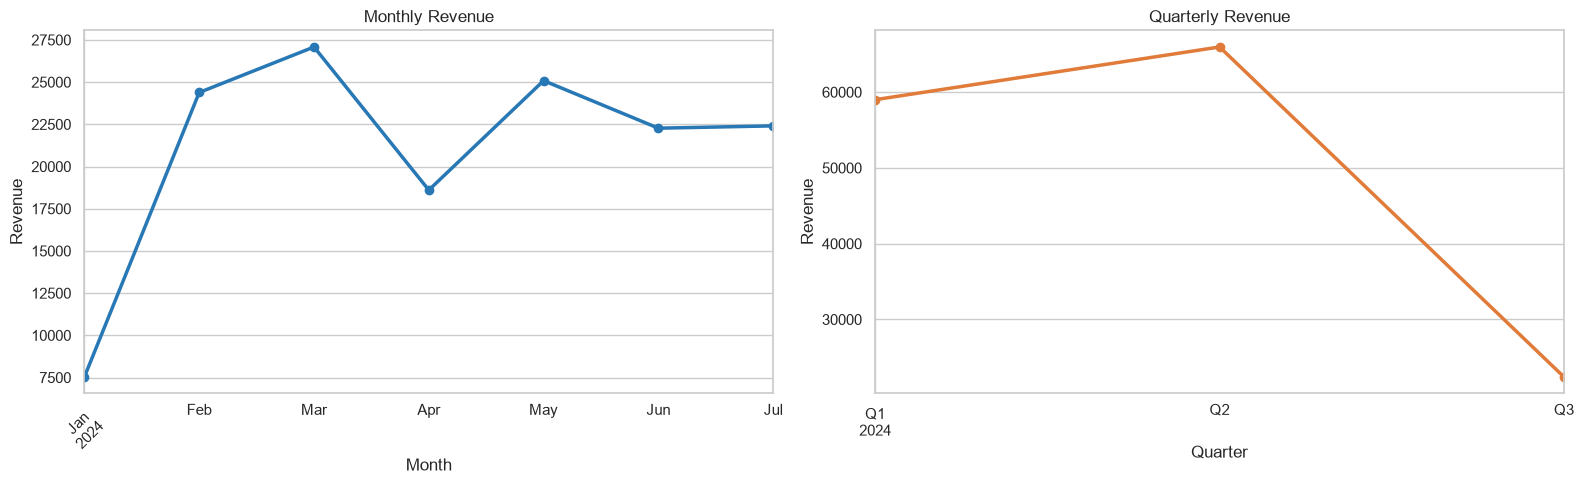

**Observation.** Revenue peaks in **2024-03** at **27,082**. The largest full-quarter total is **2024Q2** at **65,960**. The final quarter is partial, so it should not be compared as a complete quarter.

In [4]:
monthly = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum().sort_index()
quarterly = df.groupby(df['order_date'].dt.to_period('Q'))['revenue'].sum().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly.plot(ax=axes[0], marker='o', linewidth=2.5, color='#2878B5')
axes[0].set(title='Monthly Revenue', xlabel='Month', ylabel='Revenue'); axes[0].tick_params(axis='x', rotation=45)
quarterly.plot(ax=axes[1], marker='o', linewidth=2.5, color='#E07B39')
axes[1].set(title='Quarterly Revenue', xlabel='Quarter', ylabel='Revenue')
plt.tight_layout(); plt.show()
peak_month, peak_month_value = monthly.idxmax(), monthly.max()
peak_q, peak_q_value = quarterly.idxmax(), quarterly.max()
display(Markdown(f'**Observation.** Revenue peaks in **{peak_month}** at **{peak_month_value:,.0f}**. The largest full-quarter total is **{peak_q}** at **{peak_q_value:,.0f}**. The final quarter is partial, so it should not be compared as a complete quarter.'))

## 4. Customer demographics: age groups and gender

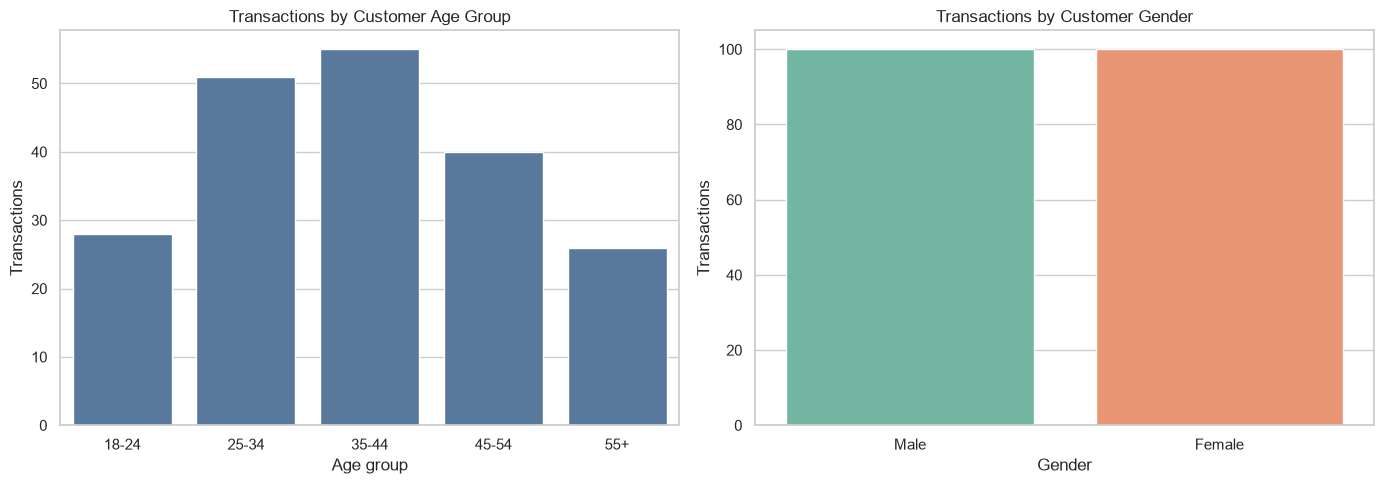

**Observation.** The **35-44** group has the most transactions (55). **Male** customers have the most transactions (100); use the revenue summaries below alongside counts.

,Age-group revenue,Transactions
age_group,,
18-24,20963,28
25-34,34067,51
35-44,40270,55
45-54,32539,40
55+,19529,26


,Gender revenue,Transactions
customer_gender,,
Female,77362,100
Male,70006,100


In [5]:
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['customer_age'], [0,24,34,44,54,float('inf')], labels=age_labels)
age_counts = df['age_group'].value_counts().reindex(age_labels, fill_value=0)
gender_counts = df['customer_gender'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set(title='Transactions by Customer Age Group', xlabel='Age group', ylabel='Transactions')
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1], hue=gender_counts.index, legend=False, palette='Set2')
axes[1].set(title='Transactions by Customer Gender', xlabel='Gender', ylabel='Transactions')
plt.tight_layout(); plt.show()
age_revenue = df.groupby('age_group', observed=False)['revenue'].sum().reindex(age_labels)
gender_revenue = df.groupby('customer_gender')['revenue'].sum().sort_values(ascending=False)
display(Markdown(f'**Observation.** The **{age_counts.idxmax()}** group has the most transactions ({age_counts.max():,}). **{gender_counts.idxmax()}** customers have the most transactions ({gender_counts.max():,}); use the revenue summaries below alongside counts.'))
display(pd.DataFrame({'Age-group revenue':age_revenue, 'Transactions':age_counts}))
display(pd.DataFrame({'Gender revenue':gender_revenue, 'Transactions':gender_counts.reindex(gender_revenue.index)}))

## 5. Product analysis

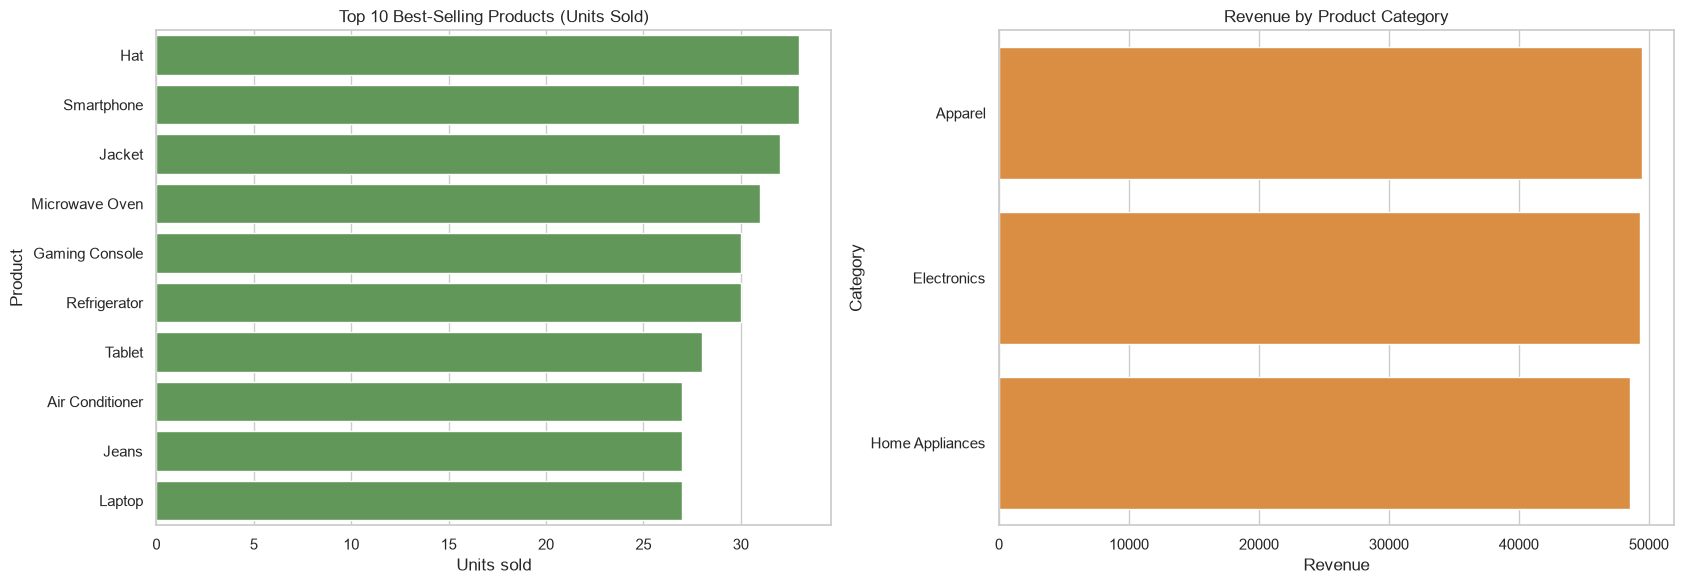

**Observation.** **Hat** leads unit sales with **33 units**. **Apparel** leads category revenue at **49,467**. Volume and revenue answer different questions, so both should guide decisions.

,product_name,quantity
0,Hat,33
1,Smartphone,33
2,Jacket,32
3,Microwave Oven,31
4,Gaming Console,30
5,Refrigerator,30
6,Tablet,28
7,Air Conditioner,27
8,Jeans,27
9,Laptop,27


In [6]:
top_products = df.groupby('product_name', as_index=False)['quantity'].sum().sort_values(['quantity','product_name'], ascending=[False,True]).head(10)
category_revenue = df.groupby('product_category', as_index=False)['revenue'].sum().sort_values('revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(17,6))
sns.barplot(data=top_products, x='quantity', y='product_name', ax=axes[0], color='#59A14F')
axes[0].set(title='Top 10 Best-Selling Products (Units Sold)', xlabel='Units sold', ylabel='Product')
sns.barplot(data=category_revenue, x='revenue', y='product_category', ax=axes[1], color='#F28E2B')
axes[1].set(title='Revenue by Product Category', xlabel='Revenue', ylabel='Category')
plt.tight_layout(); plt.show()
top_product, top_category = top_products.iloc[0], category_revenue.iloc[0]
display(Markdown(f"**Observation.** **{top_product['product_name']}** leads unit sales with **{top_product['quantity']:,.0f} units**. **{top_category['product_category']}** leads category revenue at **{top_category['revenue']:,.0f}**. Volume and revenue answer different questions, so both should guide decisions."))
display(top_products.reset_index(drop=True))

## 6. Correlation heatmap

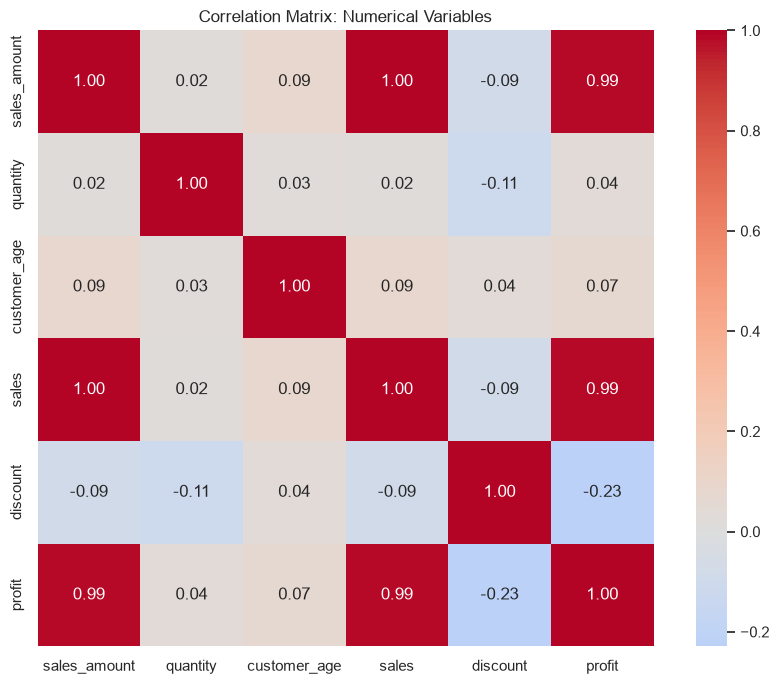

**Observation.** `sales_amount` and `sales` are perfectly correlated because the source stores the same value twice. Profit is strongly positively associated with sales amount, while discount is negatively associated with profit. Correlation is not causation.

In [7]:
# Exclude derived revenue; it duplicates sales_amount exactly.
heatmap_cols = ['sales_amount','quantity','customer_age','sales','discount','profit']
corr = df[heatmap_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix: Numerical Variables')
plt.tight_layout(); plt.show()
display(Markdown('**Observation.** `sales_amount` and `sales` are perfectly correlated because the source stores the same value twice. Profit is strongly positively associated with sales amount, while discount is negatively associated with profit. Correlation is not causation.'))

## 7. Additional insight: discount level versus profit margin

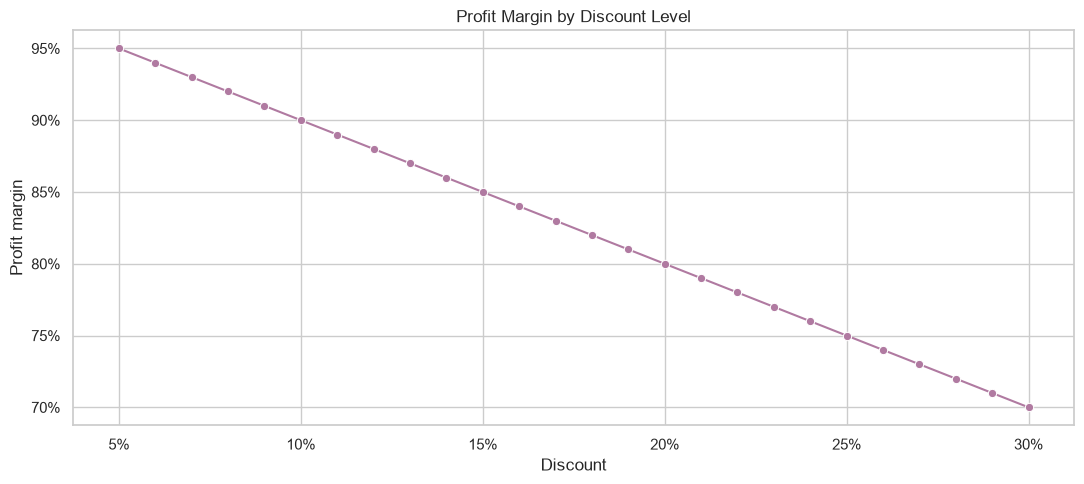

**Observation.** Margin falls from **95%** at the lowest observed discount to **70%** at the highest. This reveals a trade-off: deeper discounts reduce the share of revenue retained as profit in this dataset.

,discount,revenue,profit,profit_margin
0,0.05,5585,"5,305.75",0.95
1,0.06,5610,"5,273.40",0.94
2,0.07,7049,"6,555.57",0.93
3,0.08,6633,"6,102.36",0.92
4,0.09,4955,"4,509.05",0.91
5,0.10,6874,"6,186.60",0.90
6,0.11,5512,"4,905.68",0.89
7,0.12,5669,"4,988.72",0.88
8,0.13,3516,"3,058.92",0.87
9,0.14,4668,"4,014.48",0.86


In [8]:
discount_margin = df.groupby('discount').agg(revenue=('revenue','sum'), profit=('profit','sum')).assign(profit_margin=lambda x: x['profit']/x['revenue']).reset_index().sort_values('discount')
plt.figure(figsize=(11,5))
sns.lineplot(data=discount_margin, x='discount', y='profit_margin', marker='o', color='#B07AA1')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.gca().xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.title('Profit Margin by Discount Level'); plt.xlabel('Discount'); plt.ylabel('Profit margin')
plt.tight_layout(); plt.show()
low = discount_margin.loc[discount_margin['discount'].idxmin(), 'profit_margin']
high = discount_margin.loc[discount_margin['discount'].idxmax(), 'profit_margin']
display(Markdown(f'**Observation.** Margin falls from **{low:.0%}** at the lowest observed discount to **{high:.0%}** at the highest. This reveals a trade-off: deeper discounts reduce the share of revenue retained as profit in this dataset.'))
display(discount_margin)

## 8. Conclusion and actionable recommendations

This is exploratory analysis, not causal proof. The recommendations are grounded in the measured patterns and should be tested before broad rollout.

1. **Plan inventory and promotional capacity around the observed peak month and strongest full quarter.** Use the trend charts to schedule stock replenishment and campaigns; do not compare the partial final quarter as a full period.
2. **Prioritise the leading unit-selling products while protecting category breadth.** Keep adequate stock for top-10 products and pair this with category-level planning, because the top-revenue category may differ from the top-volume item.
3. **Target the largest age segment first, then measure incremental revenue.** Run a segmented campaign, comparing response, average order value, and repeat purchases against a control group before scaling.
4. **Set discount guardrails and test promotions.** The margin chart falls at deeper discounts. Test smaller discounts, bundles, or product-specific offers; approve deeper discounts only if incremental volume offsets the margin loss.
5. **Track demographic revenue as well as transaction count.** Count alone can hide average-order-value differences; use the demographic summaries as a baseline for future targeting.

### Limits
The source contains 200 rows across a limited time range. It cannot establish causality and lacks returns, marketing exposure, inventory, and customer-lifetime-value data. Treat this as a portfolio-quality EDA and validate actions with fuller operational data.

## Reproducibility checklist
- [x] Inspection: shape, data types, and missing values
- [x] Mean, median, mode, and standard deviation for every numerical field
- [x] Monthly and quarterly trends
- [x] Age-group and gender analysis
- [x] Top 10 products and category revenue
- [x] Numerical correlation heatmap
- [x] Additional non-obvious discount/margin insight
- [x] Observations after each chart
- [x] Evidence-based recommendations and limitations